# Processamento de Linguagem Natural (PLN)

Alunas:
- Leila Maria Biggi de Souza Cavalcante
- Maria Antonia Ribeiro Ramos

## Instalação e imports

In [31]:
# Rode esta célula uma vez para instalar a stack no kernel atual
%pip install numpy pandas nltk spacy scikit-learn kagglehub matplotlib
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 4.7 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 10.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 30.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [32]:
import string
from collections import Counter
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
import sklearn
import spacy
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("nltk", nltk.__version__)
print("spacy", spacy.__version__)
print("scikit-learn", sklearn.__version__)
print("re", re.__version__)
print("matplotlib", plt.matplotlib.__version__)

numpy 2.5.2
pandas 3.0.5
nltk 3.10.3
spacy 3.8.16
scikit-learn 1.9.0
re 2.2.1
matplotlib 3.11.1


In [33]:
# Language resources (run once)
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

# spaCy English model. If this fails, install in the terminal:
# python -m spacy download en_core_web_sm
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy: en_core_web_sm loaded")
except OSError:
    print("en_core_web_sm is not installed yet.")

stopwords_en = set(nltk.corpus.stopwords.words("english"))
print("NLTK English stopwords:", len(stopwords_en))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


spaCy: en_core_web_sm loaded
NLTK English stopwords: 198


In [34]:
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Leila\.cache\kagglehub\datasets\hgultekin\bbcnewsarchive\versions\1


## Exercícios

#### 1. Escreva uma função que recebe uma senha como entrada e verifica se ela atende aos seguintes critérios de uma senha forte:
• Pelo menos 8 caracteres  
• Pelo menos uma letra maiúscula e uma letra minúscula  
• Pelo menos um dígito  
• Pelo menos um caractere especial (por exemplo, !@#$%&*)

#### A função deve retornar True se a senha for forte e False caso contrário. Mostre exemplos.

In [35]:
# Validação por classes de caracteres (regex)
# para reconhecer padrões em texto, no nível do caractere.
PASSWORD_PATTERNS = {
    "min_length": r".{8,}",
    "uppercase": r"[A-Z]",
    "lowercase": r"[a-z]",
    "digit": r"\d",
    "special": r"[!@#$%&*]",
}


def is_strong_password(password: str) -> bool:
    """Return True if every regex pattern is found in the password."""
    if not isinstance(password, str):
        return False
    return all(re.search(pattern, password) for pattern in PASSWORD_PATTERNS.values())


examples = [
    "Abcdef1!",
    "short1!",
    "alllowercase1!",
    "ALLUPPERCASE1!",
    "NoDigits!!",
    "NoSpecial1",
    "GoodPass9@",
    #Insira mais exemplos aqui
]

for pwd in examples:
    print(f"{pwd!r:20} -> {is_strong_password(pwd)}")

'Abcdef1!'           -> True
'short1!'            -> False
'alllowercase1!'     -> False
'ALLUPPERCASE1!'     -> False
'NoDigits!!'         -> False
'NoSpecial1'         -> False
'GoodPass9@'         -> True


#### 2. Escreva uma função que recebe um endereço de e-mail como entrada e verifica se ele é válido de acordo com as regras básicas de formação de um e-mail. Utilize expressões regulares para realizar a validação. A função deve retornar True se o endereço de e-mail for válido e False caso contrário. Mostre exemplos.

In [36]:
# Regras básicas de e-mail: usuario@dominio.tld
# local: letras, dígitos e . _ % + -
# domínio: rótulos com letras, dígitos e hífen, TLD com 2+ letras
EMAIL_PATTERN = re.compile(r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$")


def is_valid_email(email: str) -> bool:
    """Return True if the string matches a basic email pattern."""
    if not isinstance(email, str):
        return False
    return EMAIL_PATTERN.fullmatch(email) is not None


examples = [
    "user@example.com",
    "first.last@university.edu",
    "name+tag@mail.co.uk",
    "missing-at-sign.com",
    "no-domain@",
    "@no-user.com",
    "spaces emma.t@example.net",
    "double@@mail.com",
    "no-tld@mail",
    #Insira mais exemplos aqui
]

for address in examples:
    print(f"{address!r:32} -> {is_valid_email(address)}")

'user@example.com'               -> True
'first.last@university.edu'      -> True
'name+tag@mail.co.uk'            -> True
'missing-at-sign.com'            -> False
'no-domain@'                     -> False
'@no-user.com'                   -> False
'spaces emma.t@example.net'      -> False
'double@@mail.com'               -> False
'no-tld@mail'                    -> False


#### 3. Considere o seguinte exemplo de referência de livro em formato de citação APA:

Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.

#### Implemente uma função usando expressões regulares que extraia cada autor, ano de publicação, título e editora do livro, para qualquer referência de livro neste formato.

In [37]:
APA_BOOK_PATTERN = re.compile(
    r"^(?P<authors>.+?)\s+\((?P<year>\d{4})\)\.\s+(?P<title>.+?)\.\s+(?P<publisher>.+?)\.?$"
)
AUTHOR_PATTERN = re.compile(r"[A-Za-z][A-Za-z'’-]+,\s+(?:[A-Z]\.\s*)+")


def parse_apa_book(reference: str) -> dict | None:
    """Extract authors, year, title and publisher from an APA book citation."""
    if not isinstance(reference, str):
        return None

    match = APA_BOOK_PATTERN.fullmatch(reference.strip())
    if not match:
        return None

    authors = [
        re.sub(r"^&\s*", "", author.group(0)).strip().rstrip(",")
        for author in AUTHOR_PATTERN.finditer(match.group("authors"))
    ]

    return {
        "authors": authors,
        "year": match.group("year"),
        "title": match.group("title"),
        "publisher": match.group("publisher").rstrip("."),
    }


examples = [
    "Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.",
    "Jurafsky, D., & Martin, J. H. (2023). Speech and language processing. Pearson.",
    "Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python. O'Reilly Media.",
    #Insira mais exemplos aqui
]

for citation in examples:
    print(citation)
    print(parse_apa_book(citation))
    print()

Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press.
{'authors': ['Manning, C. D.', 'Manning, C. D.', 'Schutze, H.'], 'year': '1999', 'title': 'Foundations of statistical natural language processing', 'publisher': 'MIT press'}

Jurafsky, D., & Martin, J. H. (2023). Speech and language processing. Pearson.
{'authors': ['Jurafsky, D.', 'Martin, J. H.'], 'year': '2023', 'title': 'Speech and language processing', 'publisher': 'Pearson'}

Bird, S., Klein, E., & Loper, E. (2009). Natural language processing with Python. O'Reilly Media.
{'authors': ['Bird, S.', 'Klein, E.', 'Loper, E.'], 'year': '2009', 'title': 'Natural language processing with Python', 'publisher': "O'Reilly Media"}



#### 4. Usando sua base de textos, determine a distribuição de comprimentos dos textos (em quantidade de palavras), listando estas quantidades e plotando um histograma.

Textos na base: 2225

Distribuição do comprimento (palavras):
count    2225.000000
mean      366.546067
std       232.934387
min        82.000000
25%       231.000000
50%       316.000000
75%       453.000000
max      4369.000000

Quantidade de palavras por texto:


,filename,category,title,n_words
0,001.txt,business,Ad sales boost Time Warner profit,383
1,002.txt,business,Dollar gains on Greenspan speech,369
2,003.txt,business,Yukos unit buyer faces loan claim,250
3,004.txt,business,High fuel prices hit BA's profits,358
4,005.txt,business,Pernod takeover talk lifts Domecq,243
...,...,...,...,...
2220,397.txt,tech,BT program to beat dialler scams,405
2221,398.txt,tech,Spam e-mails tempt net shoppers,336
2222,399.txt,tech,Be careful how you code,1034
2223,400.txt,tech,US cyber security chief resigns,366


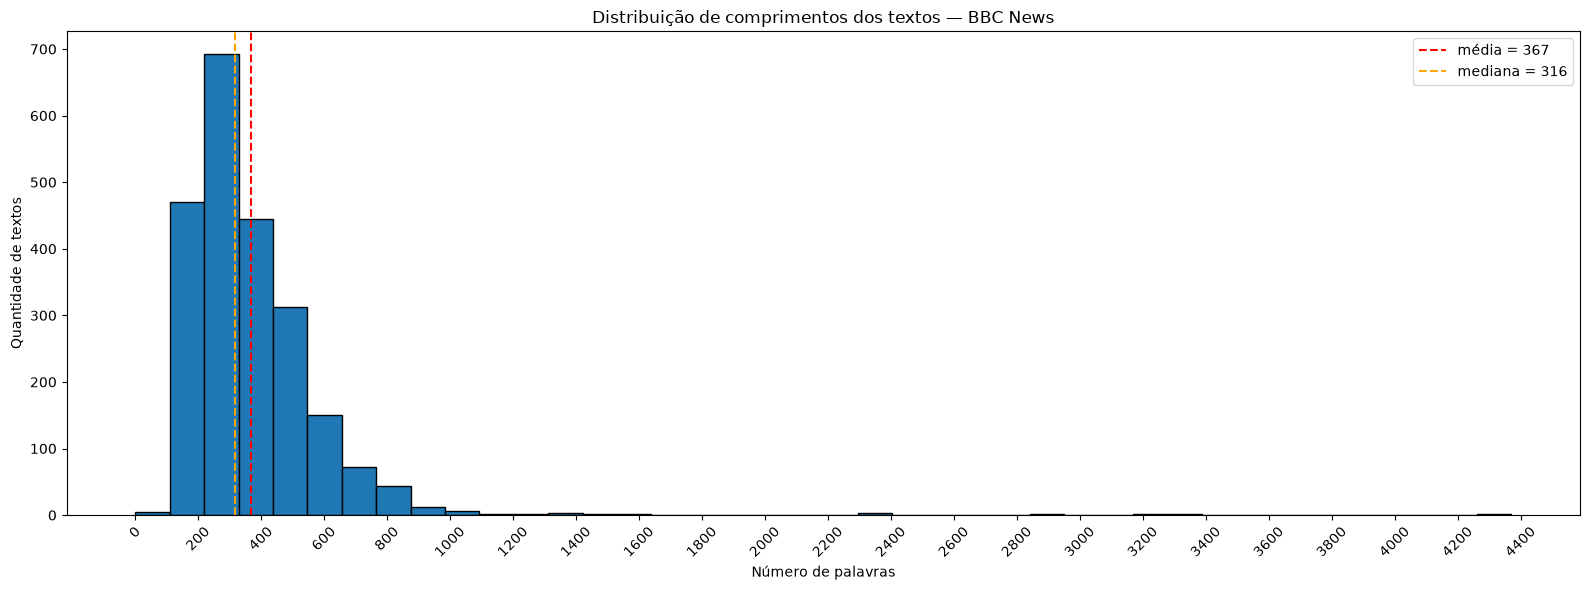

In [38]:
if "path" not in globals():
    path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

news = pd.read_csv(Path(path) / "bbc-news-data.csv", sep="\t")


def count_words(text: str) -> int:
    """Count words with NLTK tokenization (alphabetic tokens only)."""
    return sum(token.isalpha() for token in nltk.word_tokenize(str(text)))


news["n_words"] = news["content"].map(count_words)

print(f"Textos na base: {len(news)}")
print("\nDistribuição do comprimento (palavras):")
print(news["n_words"].describe().to_string())
print("\nQuantidade de palavras por texto:")
display(news[["filename", "category", "title", "n_words"]])

mean_words = news["n_words"].mean()
median_words = news["n_words"].median()
max_words = news["n_words"].max()

plt.figure(figsize=(16, 6))
plt.hist(news["n_words"], bins=40, range=(0, max_words), edgecolor="black")
plt.axvline(mean_words, color="red", linestyle="--", label=f"média = {mean_words:.0f}")
plt.axvline(median_words, color="orange", linestyle="--", label=f"mediana = {median_words:.0f}")
plt.xticks(np.arange(0, max_words + 200, 200), rotation=45)
plt.xlabel("Número de palavras")
plt.ylabel("Quantidade de textos")
plt.title("Distribuição de comprimentos dos textos — BBC News")
plt.legend()
plt.tight_layout()
plt.show()

O histograma mostra quantos textos da BBC News caem em cada faixa de comprimento (em palavras). A distribuição é **assimétrica à direita**: a maior parte das notícias tem entre **200 e 450 palavras**, com pico perto de **250–350**. A mediana (316) fica à esquerda da média (367) porque alguns textos bem mais longos puxam a média para cima. O eixo X vai até o texto mais longo (**4369 palavras**), com marcações de 200 em 200, para a cauda e os outliers (por exemplo, textos perto de 2300 e 2900 palavras) também ficarem visíveis.

#### 5. Aplique os seguintes passos de pré-processamento aos textos:
• Remova todas as palavras que contêm números;  
• Converta as palavras para minúsculas;  
• Remova pontuação;  
• Tokenize os textos em palavras, gerando um dicionário único com n tokens e convertendo cada texto em um vetor de dimensão n com a respectiva contagem de palavras.  
#### Em seguida, encontre as 10 palavras mais frequentes da base de textos.

In [39]:
def preprocess(text: str) -> list[str]:
    """Tokenize, drop tokens with digits, lowercase and strip punctuation."""
    tokens = nltk.word_tokenize(str(text))
    tokens = [token.lower() for token in tokens]
    tokens = [token for token in tokens if not any(ch.isdigit() for ch in token)]
    tokens = [token.translate(str.maketrans("", "", string.punctuation)) for token in tokens]
    return [token for token in tokens if token]


news["tokens"] = news["content"].map(preprocess)

vectorizer = CountVectorizer(
    tokenizer=lambda tokens: tokens,
    preprocessor=lambda x: x,
    lowercase=False,
    token_pattern=None,
)
bow = vectorizer.fit_transform(news["tokens"])
vocabulary = vectorizer.get_feature_names_out()
token_to_index = {token: index for index, token in enumerate(vocabulary)}
n = len(vocabulary)

print(f"Dicionário único: n = {n} tokens")
print(f"Cada texto virou um vetor de dimensão n → matriz BoW {bow.shape[0]} x {bow.shape[1]}")
print("\nAmostra do dicionário (token → índice):")
for token in list(token_to_index)[:8]:
    print(f"  {token!r:20} -> {token_to_index[token]}")

frequencies = np.asarray(bow.sum(axis=0)).ravel()
top10 = (
    pd.DataFrame({"palavra": vocabulary, "frequencia": frequencies})
    .sort_values("frequencia", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index = top10.index + 1
print("\n10 palavras mais frequentes da base:")
display(top10)

Dicionário único: n = 30048 tokens
Cada texto virou um vetor de dimensão n → matriz BoW 2225 x 30048

Amostra do dicionário (token → índice):
  'a'                  -> 0
  'aa'                 -> 1
  'aaa'                -> 2
  'aaas'               -> 3
  'aac'                -> 4
  'aadc'               -> 5
  'aaliyah'            -> 6
  'aaltra'             -> 7

10 palavras mais frequentes da base:


,palavra,frequencia
1,the,52542
2,to,24662
3,of,19893
4,and,18536
5,a,18256
6,in,17458
7,s,8950
8,for,8705
9,is,8605
10,that,8254


#### 6. Aplique os seguintes passos de pré-processamento aos textos processados na questão anterior:
• Remova stopwords;  
• Realize rotulação de POS;  
• Realize stemização;    

a) Exiba os resultados em alguns textos.  
b) Verifique quais são as 10 palavras mais frequentes e compare com as 10 palavras mais frequentes da questão anterior.  
c) Repita a letra b) usando os tokens stemizados.  
d) Verifique quais são as classes gramaticais mais frequentes.

In [41]:
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

stemmer = PorterStemmer()


def most_frequent(token_lists, n=10, col="palavra"):
    counts = Counter(token for doc in token_lists for token in doc)
    table = pd.DataFrame(counts.most_common(n), columns=[col, "frequencia"])
    table.index = table.index + 1
    return table


news["tokens_nostop"] = news["tokens"].map(
    lambda tokens: [token for token in tokens if token not in stopwords_en]
)
news["pos"] = list(nltk.pos_tag_sents(news["tokens_nostop"].tolist()))
news["stems"] = news["tokens_nostop"].map(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

print("a) Exemplos de textos após stopwords, POS e stemming\n")
for i in [0, 1, 2]:
    print("=" * 80)
    print("Título:", news.loc[i, "title"])
    print("Q5 (pré-processado):", news.loc[i, "tokens"][:20])
    print("Sem stopwords:      ", news.loc[i, "tokens_nostop"][:20])
    print("POS:                ", news.loc[i, "pos"][:20])
    print("Stems:              ", news.loc[i, "stems"][:20])
    print()

print("\nb) 10 mais frequentes: questão 5 vs. sem stopwords")
top10_q5 = most_frequent(news["tokens"])
top10_nostop = most_frequent(news["tokens_nostop"])
compare_b = pd.DataFrame({
    "Q5 — palavra": top10_q5["palavra"],
    "Q5 — freq": top10_q5["frequencia"],
    "Q6 sem stopwords — palavra": top10_nostop["palavra"],
    "Q6 sem stopwords — freq": top10_nostop["frequencia"],
})
display(compare_b)

print("\nc) 10 mais frequentes com tokens stemizados")
top10_stems = most_frequent(news["stems"], col="stem")
compare_c = pd.DataFrame({
    "sem stopwords — palavra": top10_nostop["palavra"],
    "sem stopwords — freq": top10_nostop["frequencia"],
    "stem — token": top10_stems["stem"],
    "stem — freq": top10_stems["frequencia"],
})
display(compare_c)

print("\nd) Classes gramaticais (POS) mais frequentes")
pos_counts = Counter(tag for tagged in news["pos"] for _, tag in tagged)
top_pos = pd.DataFrame(pos_counts.most_common(10), columns=["pos", "frequencia"])
top_pos.index = top_pos.index + 1

pos_meaning = {
    "NN": "substantivo singular",
    "NNS": "substantivo plural",
    "NNP": "nome próprio singular",
    "NNPS": "nome próprio plural",
    "JJ": "adjetivo",
    "JJR": "adjetivo comparativo",
    "JJS": "adjetivo superlativo",
    "VB": "verbo (forma base)",
    "VBD": "verbo no passado",
    "VBG": "gerúndio/particípio presente",
    "VBN": "particípio passado",
    "VBP": "verbo presente (não-3ª pessoa)",
    "VBZ": "verbo presente (3ª pessoa)",
    "RB": "advérbio",
    "IN": "preposição/conjunção subordinativa",
    "DT": "determinante",
    "CD": "numeral",
    "PRP": "pronome pessoal",
    "PRP$": "pronome possessivo",
}
top_pos["significado"] = top_pos["pos"].map(lambda tag: pos_meaning.get(tag, ""))
display(top_pos)

a) Exemplos de textos após stopwords, POS e stemming

Título: Ad sales boost Time Warner profit
Q5 (pré-processado): ['quarterly', 'profits', 'at', 'us', 'media', 'giant', 'timewarner', 'jumped', 'to', 'for', 'the', 'three', 'months', 'to', 'december', 'from', 'yearearlier', 'the', 'firm', 'which']
Sem stopwords:       ['quarterly', 'profits', 'us', 'media', 'giant', 'timewarner', 'jumped', 'three', 'months', 'december', 'yearearlier', 'firm', 'one', 'biggest', 'investors', 'google', 'benefited', 'sales', 'highspeed', 'internet']
POS:                 [('quarterly', 'JJ'), ('profits', 'NNS'), ('us', 'PRP'), ('media', 'NNS'), ('giant', 'JJ'), ('timewarner', 'NN'), ('jumped', 'VBD'), ('three', 'CD'), ('months', 'NNS'), ('december', 'VBP'), ('yearearlier', 'JJR'), ('firm', 'NN'), ('one', 'CD'), ('biggest', 'JJS'), ('investors', 'NNS'), ('google', 'VBP'), ('benefited', 'VBD'), ('sales', 'NNS'), ('highspeed', 'VBP'), ('internet', 'JJ')]
Stems:               ['quarterli', 'profit', 'us', 'med

,Q5 — palavra,Q5 — freq,Q6 sem stopwords — palavra,Q6 sem stopwords — freq
1,the,52542,said,7253
2,to,24662,mr,3004
3,of,19893,would,2628
4,and,18536,also,2156
5,a,18256,people,2041
6,in,17458,new,1901
7,s,8950,us,1818
8,for,8705,year,1815
9,is,8605,one,1754
10,that,8254,could,1534



c) 10 mais frequentes com tokens stemizados


,sem stopwords — palavra,sem stopwords — freq,stem — token,stem — freq
1,said,7253,said,7253
2,mr,3004,mr,3044
3,would,2628,year,2812
4,also,2156,would,2628
5,people,2041,also,2156
6,new,1901,peopl,2042
7,us,1818,new,1901
8,year,1815,us,1818
9,one,1754,one,1800
10,could,1534,game,1611



d) Classes gramaticais (POS) mais frequentes


,pos,frequencia,significado
1,NN,167086,substantivo singular
2,JJ,84478,adjetivo
3,NNS,58963,substantivo plural
4,VBD,32851,verbo no passado
5,RB,23161,advérbio
6,VBP,22114,verbo presente (não-3ª pessoa)
7,VBG,19623,gerúndio/particípio presente
8,VBN,12765,particípio passado
9,VB,9965,verbo (forma base)
10,VBZ,7493,verbo presente (3ª pessoa)
